## Import all necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


# ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

# RandomForest Model
from sklearn.ensemble import RandomForestRegressor

# Gradient Boosting REgressor Model
from sklearn.ensemble import GradientBoostingRegressor





## 1. Load the integrated raw dataset

In [ ]:
# Load integrated dataset from output of Component 2
df = pd.read_csv("/content/Traffic and Weather Merged Dataset_Atri Kar.csv")

# Convert DateTime to proper datetime format
df["DateTime"] = pd.to_datetime(df["DateTime"], dayfirst=True)

# Sort to preserve time-series order
df = df.sort_values(by=["Junction", "DateTime"])

df.head()

,DateTime,Junction,Vehicles,ID,Date,Hour,temp,humidity,precip,windspeed,cloudcover,visibility,conditions,event_name,category,impact_level
0,2015-11-01 00:00:00,1,15,20151101001,01/11/2015,0,26.1,86.2,0.552,13.0,67.1,6.9,"Rain, Partially cloudy",No Event,No Category,No Impact
1,2015-11-01 01:00:00,1,13,20151101011,01/11/2015,1,26.1,86.2,0.552,13.0,67.1,6.9,"Rain, Partially cloudy",No Event,No Category,No Impact
2,2015-11-01 02:00:00,1,10,20151101021,01/11/2015,2,26.1,86.2,0.552,13.0,67.1,6.9,"Rain, Partially cloudy",No Event,No Category,No Impact
3,2015-11-01 03:00:00,1,7,20151101031,01/11/2015,3,26.1,86.2,0.552,13.0,67.1,6.9,"Rain, Partially cloudy",No Event,No Category,No Impact
4,2015-11-01 04:00:00,1,9,20151101041,01/11/2015,4,26.1,86.2,0.552,13.0,67.1,6.9,"Rain, Partially cloudy",No Event,No Category,No Impact


## 2. Cleaning and checking the dataset

In [ ]:
# Check for missing values
df.isnull().sum()

,0
DateTime,0
Junction,0
Vehicles,0
ID,0
Date,0
Hour,0
temp,0
humidity,0
precip,0
windspeed,0


In [ ]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Quick data inspection
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   DateTime      48120 non-null  datetime64[ns]
 1   Junction      48120 non-null  int64         
 2   Vehicles      48120 non-null  int64         
 3   ID            48120 non-null  int64         
 4   Date          48120 non-null  object        
 5   Hour          48120 non-null  int64         
 6   temp          48120 non-null  float64       
 7   humidity      48120 non-null  float64       
 8   precip        48120 non-null  float64       
 9   windspeed     48120 non-null  float64       
 10  cloudcover    48120 non-null  float64       
 11  visibility    48120 non-null  float64       
 12  conditions    48120 non-null  object        
 13  event_name    48120 non-null  object        
 14  category      48120 non-null  object        
 15  impact_level  48120 non-null  object

,DateTime,Junction,Vehicles,ID,Hour,temp,humidity,precip,windspeed,cloudcover,visibility
count,48120,48120.000000,48120.000000,4.812000e+04,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000
mean,2016-09-19 06:03:56.109725696,2.180549,22.791334,2.016330e+10,11.500000,24.634364,66.026883,2.597617,19.842893,43.977057,7.308429
min,2015-11-01 00:00:00,1.000000,1.000000,2.015110e+10,0.000000,18.700000,35.400000,0.000000,9.200000,0.000000,3.100000
25%,2016-04-16 01:45:00,1.000000,9.000000,2.016042e+10,5.750000,22.700000,54.700000,0.000000,14.700000,27.000000,6.900000
50%,2016-09-30 03:30:00,2.000000,15.000000,2.016093e+10,11.500000,24.100000,66.300000,0.000000,18.200000,44.200000,7.500000
75%,2017-02-25 16:00:00,3.000000,29.000000,2.017023e+10,17.250000,26.500000,76.800000,0.900000,22.400000,60.000000,8.000000
max,2017-06-30 23:00:00,4.000000,180.000000,2.017063e+10,23.000000,32.600000,99.000000,107.500000,150.000000,99.900000,8.900000
std,NaN,0.966955,20.750063,5.944854e+06,6.922258,2.639598,13.789692,8.398423,9.464291,22.371753,0.935038


In [ ]:
# Correcting the datat types of certain columns and dropping unwanted or redundant columns

# Convert junction to categorical as it represents location, not numeric quantities
df["Junction"] = df["Junction"].astype("category")

# Drop non-informative identifiers
df = df.drop(columns=["ID", "Date"])

# Convert text columns to category
df["conditions"] = df["conditions"].astype("category")
df["event_name"] = df["event_name"].astype("category")
df["category"] = df["category"].astype("category")
df["impact_level"] = df["impact_level"].astype("category")

In [ ]:
# Junction identifiers were treated as categorical variables, as they represent location labels rather than numeric quantities

## 3. Aggregate traffic data

In [ ]:
# Verify hourly granularity of traffic data at the junction level
# This checks how many records exist for each (Junction, DateTime) combination

hourly_check = (
    df.groupby(["Junction", "DateTime"])
      .size()
      .value_counts()
)

hourly_check

,count
1,48120
0,10248


Interpretation:
The output shows that the majority of (Junction, DateTime) combinations appear exactly once, confirming that the dataset is already recorded at an hourly resolution. Some junction-hour combinations are missing, indicating data collection gaps rather than duplicate or sub-hourly records. Since the dataset is already available at hourly resolution, aggregation was verified rather than re-applied to avoid altering the original data.


In [ ]:
# Identify target variable
target_variable = "Vehicles"  # replace if column name differs

df[target_variable].describe()

,Vehicles
count,48120.000000
mean,22.791334
std,20.750063
min,1.000000
25%,9.000000
50%,15.000000
75%,29.000000
max,180.000000


Hourly vehicle count (Vehicles) is selected as the target variable as it directly represents traffic volume and serves as a measurable proxy for congestion at each junction.

## 4. Time-based Traffic Exploratory Data Analysis (EDA)

### 4.1 Create time-based features

In [ ]:
# Extract time-based features for EDA
df["hour"] = df["DateTime"].dt.hour
df["month"] = df["DateTime"].dt.month
df["day_of_week"] = df["DateTime"].dt.dayofweek  # Monday=0
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

### 4.2 Average traffic by hour of day:
Mean hourly traffic

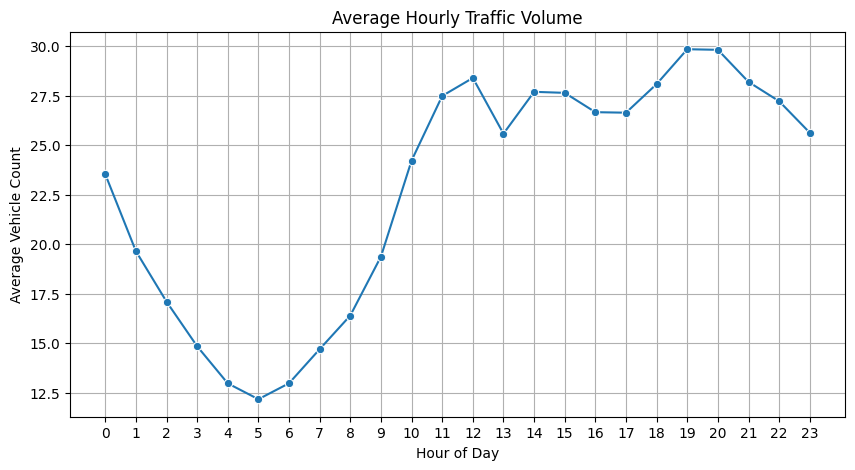

In [ ]:
hourly_avg = df.groupby("hour")["Vehicles"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_avg, x="hour", y="Vehicles", marker="o")
plt.title("Average Hourly Traffic Volume")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


Traffic volume follows a clear daily pattern, with lower volumes during late-night hours and pronounced peaks during morning (around 10 AM to 12 PM) and evening (around 7 to 8 PM). These peak periods correspond to typical commuting times and represent the most congested intervals.

### 4.3 Traffic variability by hour

Hourly traffic distribution

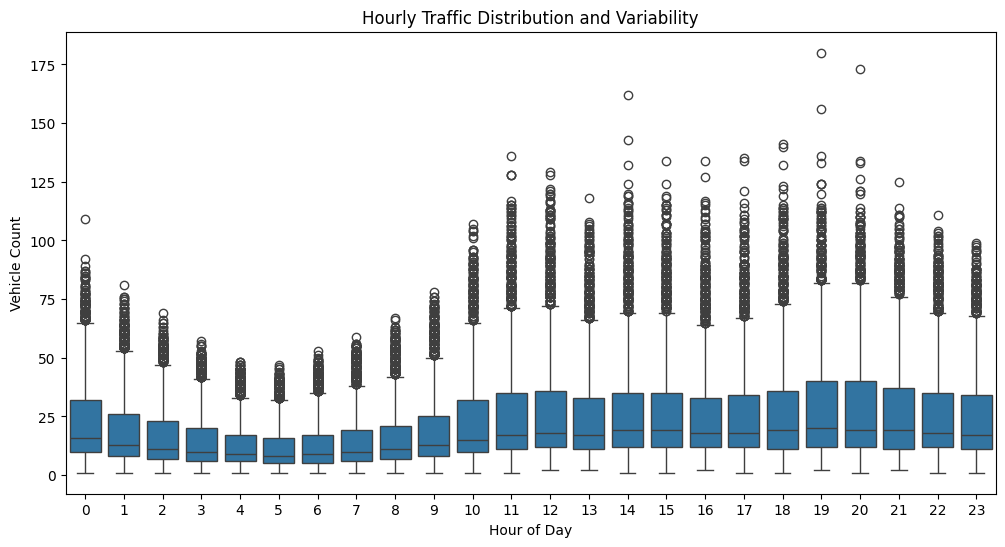

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="hour", y="Vehicles")
plt.title("Hourly Traffic Distribution and Variability")
plt.xlabel("Hour of Day")
plt.ylabel("Vehicle Count")
plt.xticks(range(0, 24))
plt.show()

Boxplots are used to examine the distribution and variability of traffic volume at each hour, highlighting periods with higher unpredictability and extreme congestion events.

Peak hours exhibit significantly higher variability compared to late-night and early-morning periods. This suggests that congestion during peak hours is more unpredictable, likely influenced by secondary factors such as weather conditions, special events, and localized disruptions.

### 4.4 Weekday vs Weekend traffic comparison

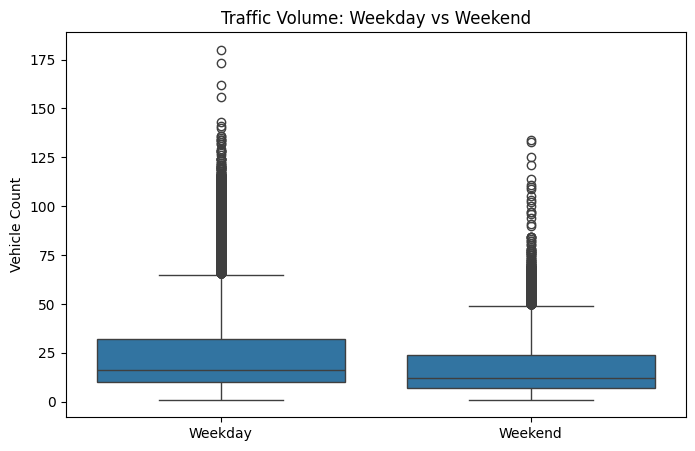

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_weekend", y="Vehicles")
plt.xticks([0, 1], ["Weekday", "Weekend"])
plt.title("Traffic Volume: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("Vehicle Count")
plt.show()

Weekdays show higher median traffic volumes and greater variability compared to weekends, reflecting regular commuting patterns. Weekend traffic is relatively more stable and lower on average.

### 4.5 Hour and Weekend interaction

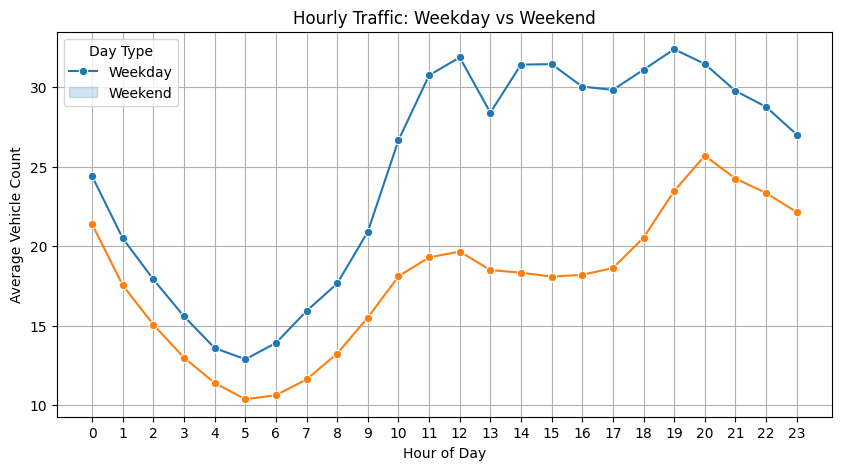

In [ ]:
hourly_weekend = (
    df.groupby(["hour", "is_weekend"])["Vehicles"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly_weekend,
    x="hour",
    y="Vehicles",
    hue="is_weekend",
    marker="o"
)
plt.title("Hourly Traffic: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.xticks(range(0, 24))
plt.legend(title="Day Type", labels=["Weekday", "Weekend"])
plt.grid(True)
plt.show()

Weekday traffic shows sharper morning and evening peaks, whereas weekend traffic is flatter throughout the day. This indicates fundamentally different temporal dynamics that should be captured in the forecasting models.

### 4.6 Summary:-

Time-based exploratory analysis reveals strong hourly and weekly traffic patterns. Peak congestion occurs during weekday morning and evening commute hours, which also show the highest variability and unpredictability. Off-peak hours and weekends exhibit more stable traffic behavior. These observations motivate the inclusion of time-based, lagged, and event-driven features in the forecasting models.

## 5. Junction-level Traffic Exploratory Data Analysis

### 5.1 Average traffic by junction
Mean traffic volume per junction

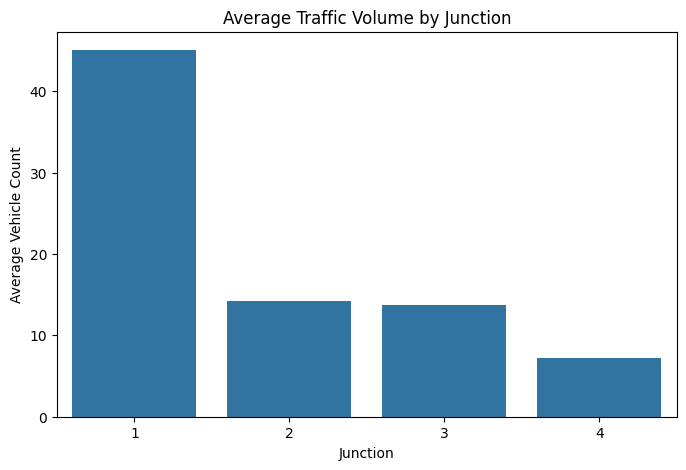

In [ ]:
junction_avg = (
    df.groupby("Junction")["Vehicles"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=junction_avg, x="Junction", y="Vehicles")
plt.title("Average Traffic Volume by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Vehicle Count")
plt.show()

Insight:
The average traffic volume varies significantly across junctions. Junction 1 consistently experiences substantially higher traffic compared to other locations, indicating a structurally congested junction. Junctions 2 and 3 show moderate and comparable traffic levels, while Junction 4 has the lowest average traffic volume. This heterogeneity across junctions highlights the need for junction-level traffic forecasting rather than a single global model.

### 5.2 Hourly traffic patterns by junction

Hourly traffic curves per junction

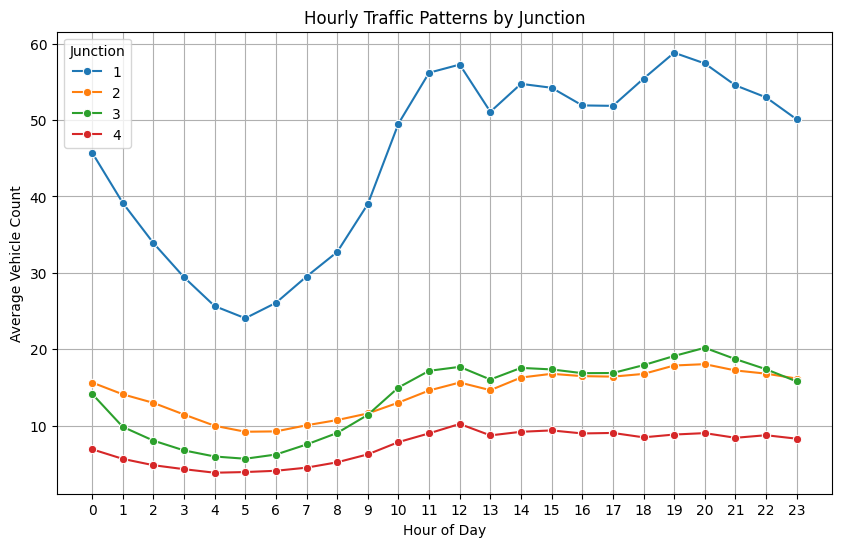

In [ ]:
junction_hourly = (
    df.groupby(["Junction", "hour"])["Vehicles"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=junction_hourly,
    x="hour",
    y="Vehicles",
    hue="Junction",
    marker="o"
)
plt.title("Hourly Traffic Patterns by Junction")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

Insight:
Hourly traffic patterns vary substantially across junctions. Junction 1 exhibits pronounced morning and evening peaks, indicating strong commuter-driven congestion. Junctions 2 and 3 show moderate traffic with smoother daily patterns, while Junction 4 maintains consistently low traffic levels throughout the day. These differences highlight distinct temporal dynamics at each junction, reinforcing the need for junction-level traffic forecasting models.

### 5.3 Traffic variability by junction

Distribution of traffic by junction

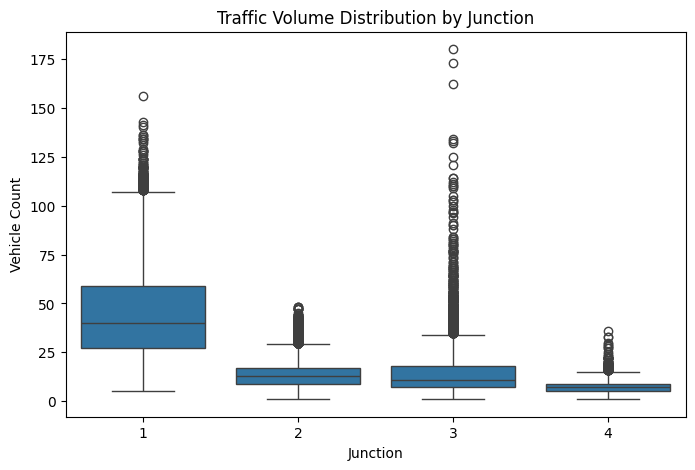

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Junction", y="Vehicles")
plt.title("Traffic Volume Distribution by Junction")
plt.xlabel("Junction")
plt.ylabel("Vehicle Count")
plt.show()

Insight:
Traffic variability differs substantially across junctions. Junction 1 exhibits both high median traffic and wide variability, indicating frequent congestion and unpredictable spikes. Junction 3 shows moderate typical traffic but extreme outliers, suggesting occasional severe congestion events. In contrast, Junctions 2 and 4 display narrower distributions and more stable traffic patterns. These differences highlight the need for junction-specific forecasting and targeted traffic management strategies.

### 5.4 Summary:-
Traffic patterns vary significantly across junctions in both volume and variability. Junction 1 consistently records the highest traffic levels and shows strong morning and evening peaks, along with high variability, indicating frequent and unpredictable congestion. Junction 3 exhibits moderate average traffic but extreme spikes, suggesting occasional severe congestion likely influenced by external factors such as events or weather. In contrast, Junctions 2 and 4 maintain lower and more stable traffic patterns throughout the day.

These differences in average traffic, peak timing, and unpredictability demonstrate that congestion dynamics are highly junction-specific. As a result, traffic forecasting must be performed at the junction level to accurately capture localized behavior and support targeted traffic management and operational decisions.

## 6. Feature Engineering and Feature Selection

### 6.1 Event-based Feature Engineering

In [ ]:
# Binary indicator for event occurrence
df["is_event"] = (df["event_name"] != "No Event").astype(int)

# Encode event impact level
impact_map = {
    "No Impact": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3
}
df["event_impact_encoded"] = df["impact_level"].map(impact_map)


Event-related features were introduced to model sudden demand shocks and explain extreme congestion spikes observed at certain junctions.

### 6.2 Weather Feature Selection

In [ ]:
# Weather features will be explicitly used during model training in Component 5

weather_features = [
    "temp", "humidity", "precip",
    "windspeed", "cloudcover", "visibility"
]

Key weather variables were retained to capture environmental conditions that may influence driving behavior and traffic congestion.

Note:- Weather features are retained for inclusion during model training.


### 6.3 Lag Feature Engineering

In [ ]:
# Sort again to be safe
df = df.sort_values(by=["Junction", "DateTime"])

# Lag features
df["lag_1h"] = df.groupby("Junction")["Vehicles"].shift(1)
df["lag_2h"] = df.groupby("Junction")["Vehicles"].shift(2)
df["lag_24h"] = df.groupby("Junction")["Vehicles"].shift(24)


Lagged traffic features were created to capture short-term and daily temporal dependencies, which are essential for time-series forecasting.

### 6.4 Handle Missing Values from Lag Features

Rows with missing values introduced by lag feature creation were removed to ensure model-ready inputs without data leakage.

In [ ]:
# Drop rows with missing lag values
df_model = df.dropna().reset_index(drop=True)

In [ ]:
df_model.shape

(47496, 23)

In [ ]:
df_model.columns

Index(['DateTime', 'Junction', 'Vehicles', 'Hour', 'temp', 'humidity',
       'precip', 'windspeed', 'cloudcover', 'visibility', 'conditions',
       'event_name', 'category', 'impact_level', 'hour', 'month',
       'day_of_week', 'is_weekend', 'is_event', 'event_impact_encoded',
       'lag_1h', 'lag_2h', 'lag_24h'],
      dtype='object')

In [ ]:
df_model.head()


,DateTime,Junction,Vehicles,Hour,temp,humidity,precip,windspeed,cloudcover,visibility,...,impact_level,hour,month,day_of_week,is_weekend,is_event,event_impact_encoded,lag_1h,lag_2h,lag_24h
0,2015-11-02 00:00:00,1,14,0,25.5,87.3,46.914,12.0,82.5,5.9,...,No Impact,0,11,0,0,0,0.0,15.0,20.0,15.0
1,2015-11-02 01:00:00,1,12,1,25.5,87.3,46.914,12.0,82.5,5.9,...,No Impact,1,11,0,0,0,0.0,14.0,15.0,13.0
2,2015-11-02 02:00:00,1,14,2,25.5,87.3,46.914,12.0,82.5,5.9,...,No Impact,2,11,0,0,0,0.0,12.0,14.0,10.0
3,2015-11-02 03:00:00,1,12,3,25.5,87.3,46.914,12.0,82.5,5.9,...,No Impact,3,11,0,0,0,0.0,14.0,12.0,7.0
4,2015-11-02 04:00:00,1,12,4,25.5,87.3,46.914,12.0,82.5,5.9,...,No Impact,4,11,0,0,0,0.0,12.0,14.0,9.0


In [ ]:
# Removing redundant hour column
df_model = df_model.drop(columns=["Hour"])


In [ ]:
df_model = df_model.drop(
    columns=[
        "conditions",
        "event_name",
        "category",
        "impact_level"
    ]
)

After feature engineering, redundant and non-informative categorical columns were removed to prevent multicollinearity and overfitting. The final dataset retains only model-relevant time, weather, event, lagged, and junction-level features, resulting in a clean and interpretable feature set for traffic forecasting.

## 7. Correlation Analysis

In [ ]:
# Select numeric features for correlation analysis
numeric_features = df_model.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr_matrix = numeric_features.corr()

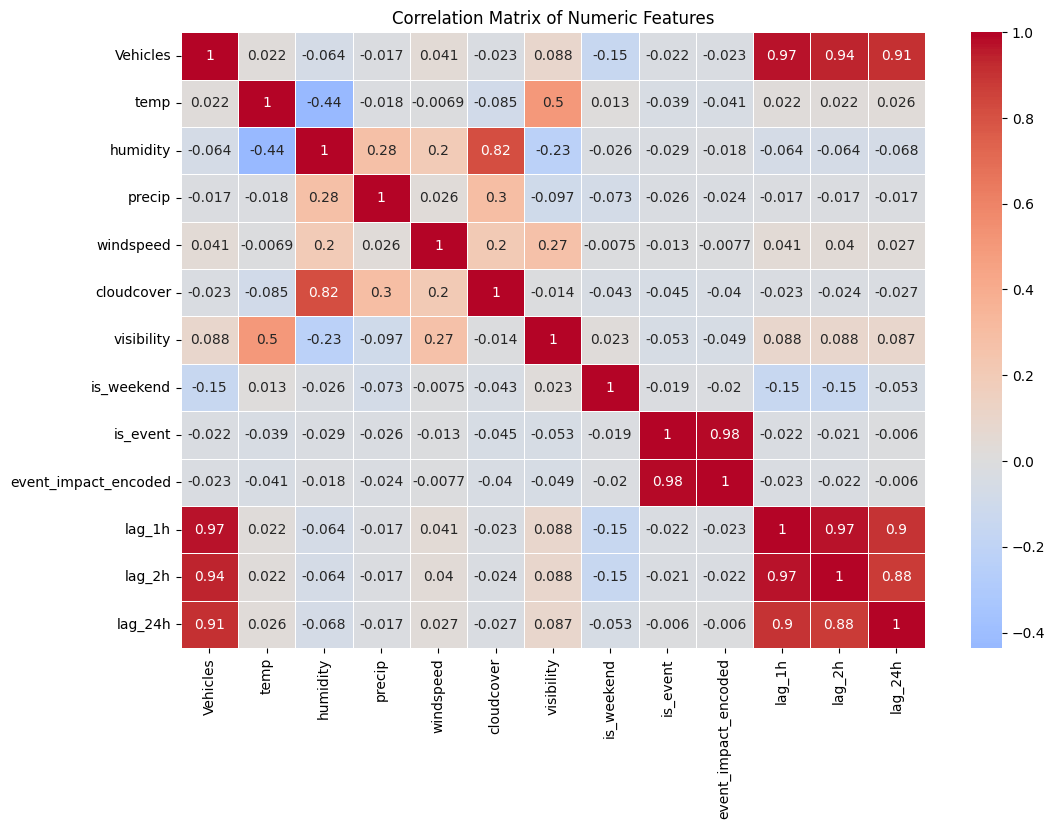

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.5, annot = True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [ ]:
# Correlation of features with target variable
vehicle_corr = (
    corr_matrix["Vehicles"]
    .sort_values(ascending=False)
)

vehicle_corr

,Vehicles
Vehicles,1.000000
lag_1h,0.970070
lag_2h,0.936927
lag_24h,0.905579
visibility,0.088265
windspeed,0.041451
temp,0.021884
precip,-0.017451
is_event,-0.022365
event_impact_encoded,-0.022912


Interpretation:

Lagged traffic variables show extremely strong positive correlation with current traffic volume. This confirms that traffic congestion exhibits strong temporal dependence, where recent and daily historical traffic levels are the most influential predictors of current congestion.

Although explicit time features (hour, weekday) are not shown here, the strong correlation of lag_24h indicates daily periodicity, reinforcing earlier EDA findings of recurring daily traffic cycles, indicating daily traffic patterns are stable and repeatable, justifying inclusion of both short-term and daily lag features.

Weather variables (temp, humidity, precip, windspeed, cloudcover, visibility) show low linear correlation with traffic volume.
Example:

visibility → ~0.09

humidity → ~-0.06

precip → ~-0.02

This  suggests that weather effects on traffic are likely non-linear and impacts may occur conditionally (e.g., during peak hours or events)

Event features are important for capturing outliers and sudden demand surges, even though their linear correlation is low.

Traffic volume is generally lower on weekends compared to weekdays, which aligns with commuter-driven congestion patterns observed during EDA.

#### NOTE: Numerical features are standardized during the modeling phase after train–test splitting to ensure comparability across variables while preventing data leakage.

## 8. Peak Hour Identification and Pattern Analysis

### 8.1 Congestion Metric Definition and Calculation

Since speed data is unavailable, average vehicle count per hour is used as a proxy for congestion, as higher traffic volumes typically indicate reduced flow efficiency..

In [ ]:
# Average traffic volume per hour for each junction
hourly_congestion = (
    df.groupby(["Junction", "hour"])["Vehicles"]
      .mean()
      .reset_index(name="avg_vehicle_count")
)

hourly_congestion.head()


,Junction,hour,avg_vehicle_count
0,1,0,45.738487
1,1,1,39.156250
2,1,2,33.907895
3,1,3,29.430921
4,1,4,25.654605


### 8.2 Identify Peak Hours per Junction

Peak hour = hour with maximum average congestion

In [ ]:
peak_hours = (
    hourly_congestion
    .loc[hourly_congestion.groupby("Junction")["avg_vehicle_count"].idxmax()]
    .sort_values("Junction")
)

peak_hours

,Junction,hour,avg_vehicle_count
19,1,19,58.804276
44,2,20,18.060855
68,3,20,20.200658
84,4,12,10.237569


### 8.3 Consistency Check Using Moving Averages

A 3-hour moving average was applied to smooth short-term fluctuations and identify sustained peak congestion periods rather than isolated hourly spikes.

In [ ]:
# Smooth hourly congestion to identify consistent peak periods
hourly_congestion["rolling_avg_3h"] = (
    hourly_congestion
    .groupby("Junction")["avg_vehicle_count"]
    .rolling(window=3, center=True)
    .mean()
    .reset_index(level=0, drop=True)
)

hourly_congestion.head()


,Junction,hour,avg_vehicle_count,rolling_avg_3h
0,1,0,45.738487,NaN
1,1,1,39.156250,39.600877
2,1,2,33.907895,34.165022
3,1,3,29.430921,29.664474
4,1,4,25.654605,26.384320


### 8.4 Weekday vs Weekend

In [ ]:
weekday_hourly = (df.groupby(["Junction", "is_weekend", "hour"])["Vehicles"].mean().reset_index())


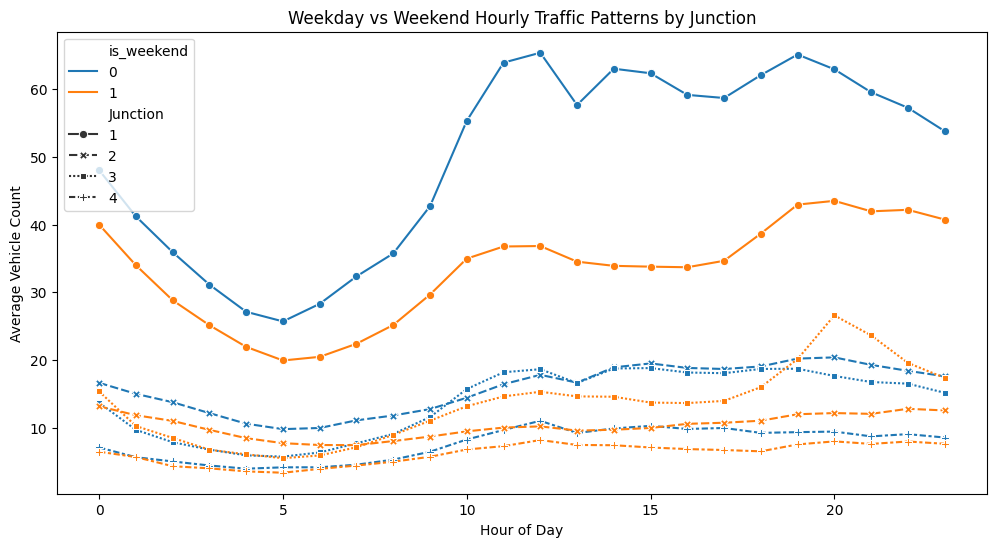

In [ ]:
# Visualisation
plt.figure(figsize=(12,6))
sns.lineplot(
    data=weekday_hourly,
    x="hour",
    y="Vehicles",
    hue="is_weekend",
    style="Junction",
    markers=True
)
plt.title("Weekday vs Weekend Hourly Traffic Patterns by Junction")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.show()

Insight:-
Weekday traffic exhibits sharper morning and evening peaks driven by commuting patterns, while weekend congestion is flatter and shifts toward late afternoon and evening hours.

### 8.5 Monthly Variations in Peak Hours

In [ ]:
monthly_hourly = (df.groupby(["Junction", "month", "hour"])["Vehicles"].mean().reset_index())

monthly_hourly.head()


,Junction,month,hour,Vehicles
0,1,1,0,41.741935
1,1,1,1,36.096774
2,1,1,2,31.629032
3,1,1,3,28.806452
4,1,1,4,25.209677


In [ ]:
# Peak month-hour combinations

monthly_peaks = (
    monthly_hourly
    .sort_values(["Junction", "Vehicles"], ascending=[True, False])
    .groupby("Junction")
    .head(3)
)

monthly_peaks

,Junction,month,hour,Vehicles
139,1,6,19,72.716667
132,1,6,12,72.150000
131,1,6,11,70.950000
427,2,6,19,25.416667
428,2,6,20,24.083333
403,2,5,19,23.951613
668,3,4,20,29.216667
669,3,4,21,28.633333
667,3,4,19,26.150000
999,4,6,15,12.133333


Insight:-Seasonal variations show moderate changes in peak intensity, with higher congestion observed during specific months, likely reflecting seasonal travel and event patterns.

### 8.6 Impact of external factors on peak hours

In [ ]:
# Impact of Event on Peak hours
peak_hour_data = df.merge(peak_hours[["Junction", "hour"]], on=["Junction", "hour"],how="inner")

peak_hour_data.groupby("is_event")["Vehicles"].mean()


,Vehicles
is_event,
0,30.570175
1,24.238806


Insight:
Average traffic volume during identified peak hours is lower on event days as compared to non-event days. This may suggest that during special events, regular commuters shift their travel time to off peak commuting periods rather than intensifying congestion during standard peak hours.

In [ ]:
#Influence of weather during peak hours

weather_corr_peak = (peak_hour_data[
    ["Vehicles", "temp", "humidity",
     "precip", "windspeed", "visibility"]].corr()["Vehicles"]
                     .sort_values(ascending=False))

weather_corr_peak


,Vehicles
Vehicles,1.000000
visibility,0.104573
windspeed,0.056557
temp,0.021781
precip,-0.028889
humidity,-0.077221


Insight:- Weather variables show weak linear correlation with traffic during peak hours, suggesting their impact is non-linear or conditional rather than continuous.

## 9. Visualisation and Reporting

### 9.1 Junction and Hour Heatmap

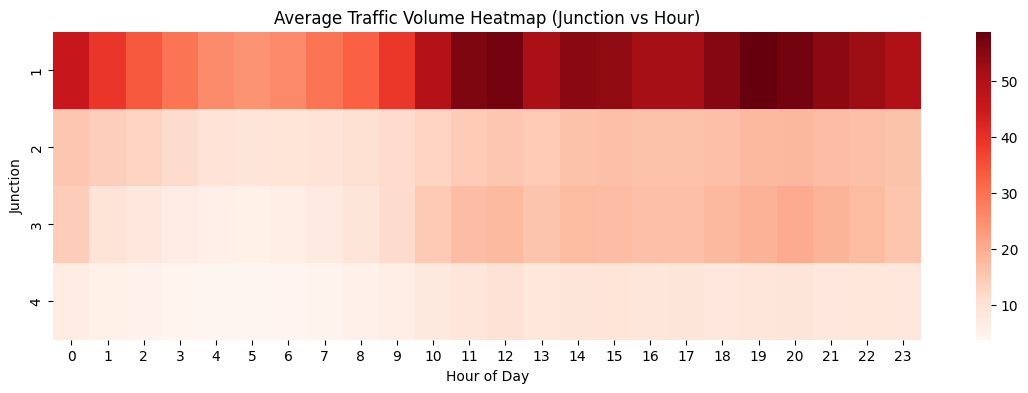

In [ ]:
heatmap_data = df.pivot_table(
    values="Vehicles",
    index="Junction",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(14,4))
sns.heatmap(heatmap_data, cmap="Reds")
plt.title("Average Traffic Volume Heatmap (Junction vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Junction")
plt.show()

Insight:
The heatmap shows distinct hourly congestion patterns across junctions. Junction 1 experiences consistently high traffic throughout the day, with pronounced peaks during late morning and evening hours. Junctions 2 and 3 show moderate congestion concentrated mainly during afternoon and evening periods, while Junction 4 maintains low and stable traffic levels across all hours. These patterns confirm that peak congestion timing and intensity vary significantly by junction, reinforcing the need for junction-specific traffic management strategies.

Note: Annotations are unnecessary here because the heatmap is used for pattern recognition rather than precise value comparison.


### 9.2 Peak Hour Summary Bar Chart

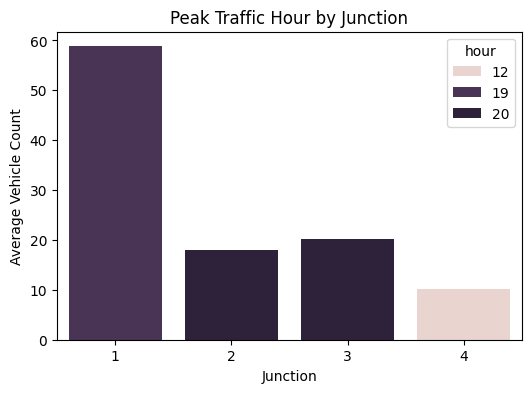

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=peak_hours,
    x="Junction",
    y="avg_vehicle_count",
    hue="hour"
)
plt.title("Peak Traffic Hour by Junction")
plt.ylabel("Average Vehicle Count")
plt.show()

Insight:-
The observed peak traffic hours across junctions align closely with commuter and local activity patterns. Junction 1 shows a strong evening peak (7 to 8 PM), indicating heavy post-office commuter and ride-hailing demand typical of major commercial corridors. Junctions 2 and 3 experience moderate evening peaks, suggesting  feeder routes connecting residential areas to busier zones. In contrast, Junction 4 peaks around midday, may be due to localized, non-commuter travel such as short errands or institutional movement. These patterns indicate that congestion dynamics are shaped by land use and daily activity schedules rather than uniform city-wide behavior.

### 9.3 Hour and DayofWeek Heatmap

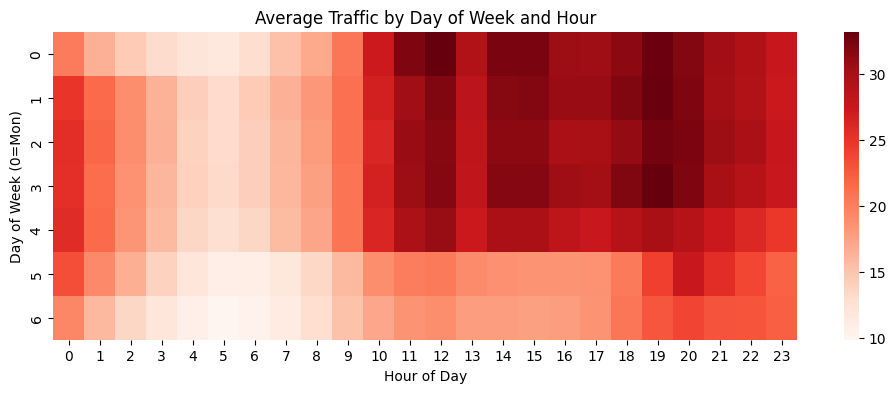

In [ ]:
dow_heatmap = df.pivot_table(
    values="Vehicles",
    index="day_of_week",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(12,4))
sns.heatmap(dow_heatmap, cmap="Reds")
plt.title("Average Traffic by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Mon)")
plt.show()

Insight:
The heatmap reveals clear weekday–weekend differences in traffic patterns. Weekdays (Monday to Friday) show pronounced morning and evening congestion peaks, reflecting regular commuting behavior. In contrast, weekend traffic is more evenly distributed across the day, with milder peaks occurring later in the afternoon and evening. This indicates that peak congestion is strongly driven by weekday work schedules rather than uniform daily demand.

### 9.4 Monthly peak-hour trend

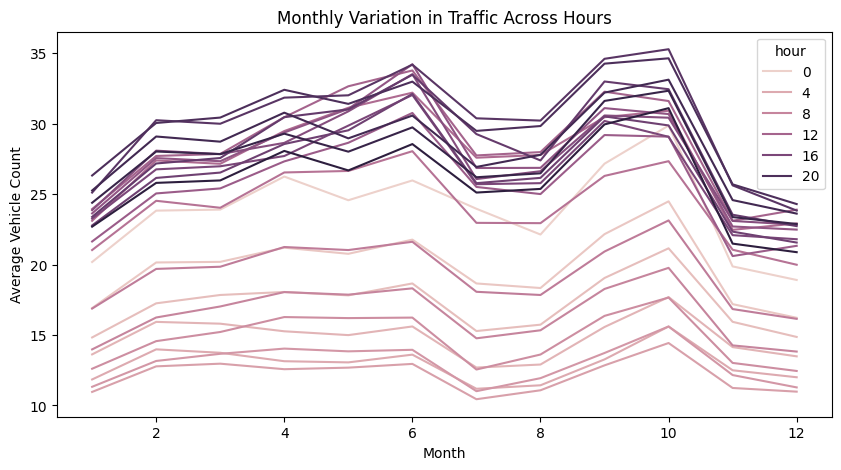

In [ ]:
monthly_peak = (
    df.groupby(["month", "hour"])["Vehicles"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=monthly_peak,
    x="month",
    y="Vehicles",
    hue="hour"
)
plt.title("Monthly Variation in Traffic Across Hours")
plt.xlabel("Month")
plt.ylabel("Average Vehicle Count")
plt.show()


Insight:
Traffic volume exhibits moderate seasonal variation across months, with higher congestion levels observed during certain periods of the year, particularly around late summer and early autumn. While the relative ranking of peak hours remains consistent, overall traffic intensity increases during these months, suggesting the influence of seasonal travel patterns, festivals, or increased urban activity. This indicates that peak congestion is affected not only by time of day but also by seasonal demand fluctuations.

### 9.5 Event vs Non-event peak-hour comparison

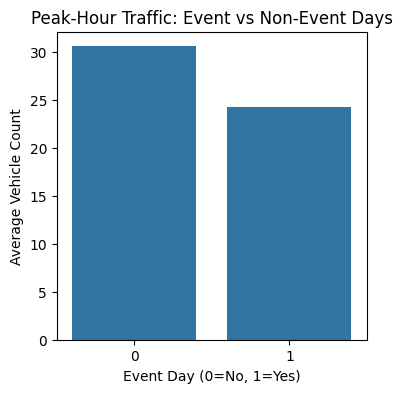

In [ ]:
event_peak = (
    peak_hour_data.groupby("is_event")["Vehicles"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(4,4))
sns.barplot(data=event_peak, x="is_event", y="Vehicles")
plt.title("Peak-Hour Traffic: Event vs Non-Event Days")
plt.xlabel("Event Day (0=No, 1=Yes)")
plt.ylabel("Average Vehicle Count")
plt.show()


Insight:
Average traffic volume during identified peak hours is lower on event days compared to non-event days. This suggests that special events tend to redistribute travel demand outside regular commuting peaks rather than intensifying congestion during standard peak hours. Commuters may adjust travel timing or routes on event days, leading to a flattening of typical peak-hour congestion.

## 10. Begin Junction wise EDA

This section explores traffic congestion patterns at the junction level.  
The objective is to understand temporal trends, peak hours, and variability across junctions before building forecasting models.

Junction-wise analysis is critical because each junction represents a distinct traffic environment with different congestion dynamics.

Note: This is the part where Component 5: Trained Models begins.

### 10.1 Convert DateTime & extract basic time features

In [ ]:
# Ensure DateTime column is in datetime format
df_model['DateTime'] = pd.to_datetime(df_model['DateTime'])

# Extract day of week (0 = Monday, 6 = Sunday)
df_model['day_of_week'] = df_model['DateTime'].dt.dayofweek

# Weekend indicator
df_model['is_weekend'] = df_model['day_of_week'].isin([5, 6]).astype(int)

### 10.2 Traffic Volume Trend Over Time by Junction

This visualization shows how traffic volume evolves over time at each junction.
It helps identify long-term trends and relative congestion intensity across locations.

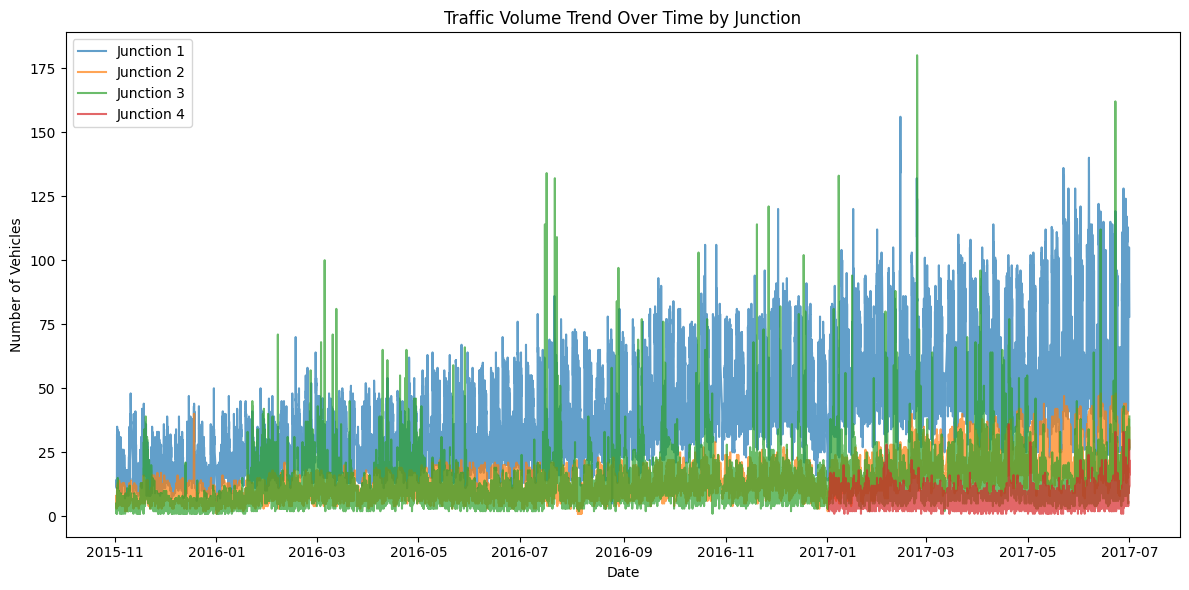

In [ ]:
plt.figure(figsize=(12, 6))

for junction in df_model['Junction'].unique():
    df_junction = df_model[df_model['Junction'] == junction]
    plt.plot(
        df_junction['DateTime'],
        df_junction['Vehicles'],
        label=f'Junction {junction}',
        alpha=0.7
    )

plt.title('Traffic Volume Trend Over Time by Junction')
plt.xlabel('Date')
plt.ylabel('Number of Vehicles')
plt.legend()
plt.tight_layout()
plt.show()

Insight:-
- Traffic volume differs significantly across junctions.
- Some junctions consistently experience higher congestion levels.
- Certain junctions exhibit higher volatility, indicating less predictable traffic behavior.


### 10.3 Average Hourly Traffic Pattern by Junction

This analysis examines how traffic congestion varies across hours of the day for each junction.
Understanding peak and off-peak hours is essential for effective traffic planning.

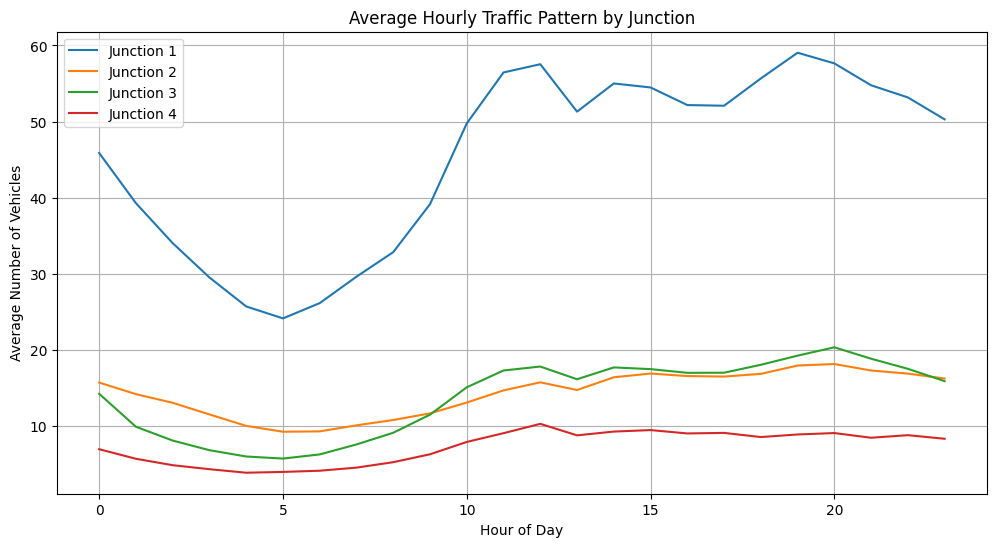

In [ ]:
# Compute average traffic by hour for each junction
hourly_pattern = (
    df_model
    .groupby(['Junction', 'hour'])['Vehicles']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for junction in hourly_pattern['Junction'].unique():
    subset = hourly_pattern[hourly_pattern['Junction'] == junction]
    plt.plot(
        subset['hour'],
        subset['Vehicles'],
        label=f'Junction {junction}'
    )

plt.title('Average Hourly Traffic Pattern by Junction')
plt.xlabel('Hour of Day')
plt.ylabel('Average Number of Vehicles')
plt.legend()
plt.grid(True)
plt.show()


Insight:-
- Clear morning and evening peak hours are observed across most junctions.
- The intensity and timing of peak congestion differ by junction.
- These differences justify junction-specific forecasting models rather than a single global model.

### 10.4 Junction-wise Traffic Variability Analysis

To identify which junctions are most unpredictable, traffic variability is measured using the standard deviation of vehicle counts.
Higher variability indicates greater forecasting difficulty.


In [ ]:
# Compute mean and standard deviation of traffic volume per junction
junction_variability = (
    df_model
    .groupby('Junction')['Vehicles']
    .agg(['mean', 'std'])
    .reset_index()
    .sort_values(by='std', ascending=False)
)

junction_variability


,Junction,mean,std
0,1,45.237569,23.030138
2,3,13.769028,10.473132
1,2,14.307431,7.407714
3,4,7.276769,3.525722


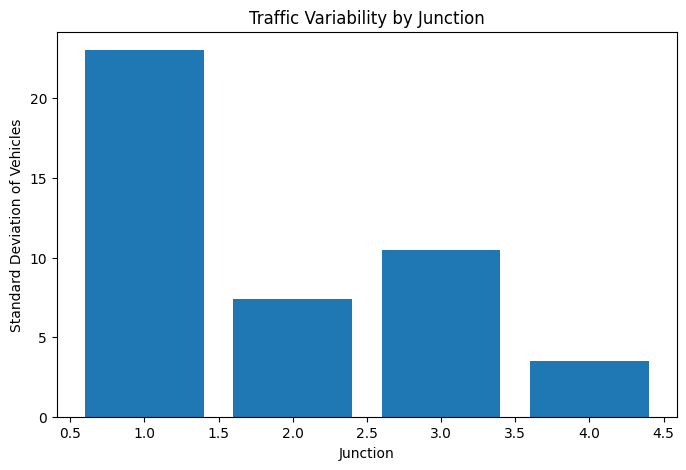

In [ ]:
# Visualize traffic variability across junctions
plt.figure(figsize=(8, 5))
plt.bar(
    junction_variability['Junction'],
    junction_variability['std']
)
plt.title('Traffic Variability by Junction')
plt.xlabel('Junction')
plt.ylabel('Standard Deviation of Vehicles')
plt.show()


Insight:-

- Junctions with higher standard deviation show more unpredictable traffic patterns.
- Such junctions may require adaptive traffic management strategies.
- These junctions are expected to benefit most from advanced machine learning models.


### Summary of Junction-wise EDA

Exploratory analysis reveals significant heterogeneity in traffic patterns across junctions, with Junction 1 exhibiting the highest congestion levels and variability, while Junction 4 remains consistently low and predictable. These differences justify junction-wise forecasting and model comparison.

- Traffic congestion patterns vary significantly across junctions and time periods.
- Peak congestion hours differ by junction, reinforcing the need for localized forecasting.
- Junctions with high variability pose greater prediction challenges and require robust models.

Based on these findings, traffic forecasting will be performed separately for each junction, using multiple models to identify the most accurate approach per location.


## 11. Junction-wise Feature Engineering and Time-based Train-Test Split

In this section, lag-based and rolling statistical features are created to capture temporal dependencies in traffic congestion.
The dataset is then split into training and validation sets using a time-based split, ensuring that future data is not leaked into the training process.

### 11.1 Feature Engineering (Lag & Rolling Features)

In [ ]:
# Create lag features
df_model['lag_1'] = df_model.groupby('Junction')['Vehicles'].shift(1)
df_model['lag_2'] = df_model.groupby('Junction')['Vehicles'].shift(2)
df_model['lag_24'] = df_model.groupby('Junction')['Vehicles'].shift(24)

# Create rolling mean features
df_model['roll_mean_3'] = (
    df_model.groupby('Junction')['Vehicles'].shift(1).rolling(window=3).mean())

df_model['roll_mean_6'] = (
    df_model.groupby('Junction')['Vehicles'].shift(1).rolling(window=6).mean())

df_model['roll_mean_24'] = (
    df_model.groupby('Junction')['Vehicles'].shift(1).rolling(window=24).mean())

# Drop rows with NaNs introduced by lagging
df_model_fe = df_model.dropna().reset_index(drop=True)


Explanation:

- Lag features capture short-term and daily temporal dependencies
- Rolling averages smooth short-term fluctuations
- These features are especially useful for tree-based models

### 11.2 Define Feature Set and Target

In [ ]:
target = 'Vehicles'

feature_cols = [
    'hour',
    'day_of_week',
    'is_weekend',
    'temp',
    'humidity',
    'precip',
    'windspeed',
    'cloudcover',
    'lag_1',
    'lag_2',
    'lag_24',
    'roll_mean_3',
    'roll_mean_6',
    'roll_mean_24'
]


### 11.3 Junction-wise Time-based Train/Test Split

In [ ]:
from collections import defaultdict

# Dictionary to store splits for each junction
junction_data = defaultdict(dict)

for junction in df_model_fe['Junction'].unique():

    df_j = (df_model_fe[df_model_fe['Junction'] == junction].sort_values('DateTime'))

    split_index = int(len(df_j) * 0.8)

    train_df = df_j.iloc[:split_index]
    test_df = df_j.iloc[split_index:]

    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    junction_data[junction]['X_train'] = X_train
    junction_data[junction]['y_train'] = y_train
    junction_data[junction]['X_test'] = X_test
    junction_data[junction]['y_test'] = y_test


Why time-based splitting?
- Preserves temporal order
- Simulates real-world forecasting
- Prevents data leakage

### 11.4 Sanity Check

In [ ]:
for j in junction_data:
    print(
        f"Junction {j} | "
        f"Train size: {junction_data[j]['X_train'].shape[0]} | "
        f"Test size: {junction_data[j]['X_test'].shape[0]}"
    )


Junction 1 | Train size: 11500 | Test size: 2876
Junction 2 | Train size: 11500 | Test size: 2876
Junction 3 | Train size: 11500 | Test size: 2876
Junction 4 | Train size: 3417 | Test size: 855


The sanity check confirms that each junction was split independently using a time-based approach. Junctions 1, 2 and 3 have comparable data volumes, while Junction 4 has fewer observations due to shorter data availability, which is handled appropriately in the modeling process.

### 11.5 Feature Scaling for Machine Learning Models

Feature scaling is applied to ensure numerical stability and balanced feature contribution for machine learning models.
Scaling is performed after time-based splitting to prevent data leakage.
It is applied only to models that use multivariate feature sets.

**Note:**
- Scaling is applied only to Random Forest and Gradient Boosting models.
- ARIMA models are trained separately using raw traffic time series data.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Dictionary to store scaled datasets per junction
scaled_junction_data = {}

for junction in junction_data:

    X_train = junction_data[junction]['X_train']
    X_test = junction_data[junction]['X_test']
    y_train = junction_data[junction]['y_train']
    y_test = junction_data[junction]['y_test']

    scaler = StandardScaler()

    # Fit scaler on training data only
    X_train_scaled = scaler.fit_transform(X_train)

    # Apply same scaler to test data
    X_test_scaled = scaler.transform(X_test)

    scaled_junction_data[junction] = {
        'X_train_scaled': X_train_scaled,
        'X_test_scaled': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler
    }


## 12. Junction-wise Model Training & Evaluation

In this section, multiple forecasting models are trained **separately for each junction**.
The performance of ARIMA, Random Forest, and Gradient Boosting models is compared using standard regression metrics.

### 12.1 Evaluation Metrics

In [ ]:
def evaluate_model(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }


### 12.2 ARIMA Model (Baseline Time-Series Model)

ARIMA is used as a baseline univariate time-series forecasting model.
It captures temporal dependencies using only historical traffic data.


In [ ]:
arima_results = []

for junction in df_model_fe['Junction'].unique():

    df_j = (
        df_model_fe[df_model_fe['Junction'] == junction]
        .sort_values('DateTime')
    )

    split_index = int(len(df_j) * 0.8)

    train_series = df_j['Vehicles'].iloc[:split_index]
    test_series = df_j['Vehicles'].iloc[split_index:]

    # Fit ARIMA model (simple baseline order)
    model = ARIMA(train_series, order=(1, 1, 1))
    model_fit = model.fit()

    predictions = model_fit.forecast(steps=len(test_series))

    metrics = evaluate_model(test_series, predictions)
    metrics['Junction'] = junction
    metrics['Model'] = 'ARIMA'

    arima_results.append(metrics)

### 12.3 Random Forest Regressor

Random Forest models are trained using engineered features and scaled inputs.
They are robust to nonlinear relationships and handle feature interactions effectively.

In [ ]:
rf_results = []

for junction in scaled_junction_data:

    data = scaled_junction_data[junction]

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42
    )

    rf.fit(data['X_train_scaled'], data['y_train'])

    predictions = rf.predict(data['X_test_scaled'])

    metrics = evaluate_model(data['y_test'], predictions)
    metrics['Junction'] = junction
    metrics['Model'] = 'Random Forest'

    rf_results.append(metrics)

### 12.4 Gradient Boosting Regressor

Gradient Boosting is used to improve predictive performance by sequentially correcting errors from previous models.
It is particularly effective for structured tabular data.

In [ ]:
gb_results = []

for junction in scaled_junction_data:

    data = scaled_junction_data[junction]

    gb = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    gb.fit(data['X_train_scaled'], data['y_train'])

    predictions = gb.predict(data['X_test_scaled'])

    metrics = evaluate_model(data['y_test'], predictions)
    metrics['Junction'] = junction
    metrics['Model'] = 'Gradient Boosting'

    gb_results.append(metrics)

### 12.5  Model Performance Comparison

The table below summarizes the performance of all models across junctions using MAE, RMSE, and R² metrics.
Lower MAE/RMSE and higher R² indicate better performance.

In [ ]:
results_df = pd.DataFrame(arima_results + rf_results + gb_results)
results_df.sort_values(['Junction', 'RMSE'])

,MAE,RMSE,R2,Junction,Model
8,4.271424,6.277666,0.929822,1,Gradient Boosting
4,4.763771,6.822098,0.917122,1,Random Forest
0,26.121383,33.357151,-0.981448,1,ARIMA
5,3.271514,4.389117,0.718664,2,Random Forest
9,3.272602,4.522903,0.701252,2,Gradient Boosting
1,6.979931,8.433435,-0.038675,2,ARIMA
6,3.148302,5.781535,0.694863,3,Random Forest
10,3.136787,5.839437,0.688720,3,Gradient Boosting
2,8.935149,11.419934,-0.190519,3,ARIMA
7,2.143801,3.181004,0.440499,4,Random Forest


### 12.6 Model Performance Comparison and Interpretation

The table above presents a comparative evaluation of ARIMA, Random Forest, and Gradient Boosting models across all junctions using MAE, RMSE, and R² as performance metrics. These metrics together provide a comprehensive view of prediction accuracy, error magnitude, and explanatory power.

Across all junctions, tree-based machine learning models (Random Forest and Gradient Boosting) consistently outperform the ARIMA baseline. This indicates that traffic congestion patterns are influenced not only by past traffic values but also by external factors such as time of day, weather conditions, and short-term temporal dependencies, which are effectively captured by multivariate models.

At **Junction 1**, which exhibits the highest traffic volume and variability, **Gradient Boosting** achieves the best performance with the **lowest RMSE and highest R²**. This suggests that Gradient Boosting is particularly effective in handling complex, highly nonlinear traffic dynamics and sudden congestion fluctuations at major junctions.

For **Junctions 2, 3, and 4**, **Random Forest** marginally outperforms Gradient Boosting. These junctions show relatively lower traffic volumes and more stable patterns, where Random Forest's ensemble averaging provides robust and consistent predictions without overfitting to noise.

The ARIMA model records negative R² values across all junctions, indicating performance lower than a mean-based predictor. This behavior is expected, as ARIMA is a univariate time-series model that relies solely on historical traffic data and cannot incorporate exogenous variables such as weather conditions, calendar effects, or abrupt traffic spikes. As a result, its predictive capability is limited in complex urban traffic environments.

Overall, these results strongly validate the need for **junction-wise forecasting** and demonstrate the effectiveness of **multivariate machine learning models** for traffic congestion prediction. The findings highlight that model performance varies by junction characteristics, reinforcing the importance of selecting the most suitable model for each location rather than relying on a single global forecasting approach.

### 12.7 Prediction Diagnostics (Best Model per Junction)

To systematically evaluate model performance across all junctions, diagnostic plots were generated in a loop.
For each junction, the best-performing model identified during evaluation was retrained and used to generate:
- Actual vs Predicted plots
- Residuals over time
- Residual distribution plots

This approach ensures consistent and comparable error analysis while avoiding redundant visualizations for suboptimal models.


In [ ]:
# Selecting the best performking model for each junction:
best_models = {
    1: 'GradientBoosting',
    2: 'RandomForest',
    3: 'RandomForest',
    4: 'RandomForest'
}

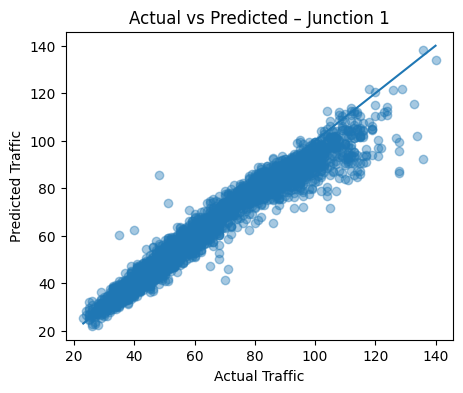

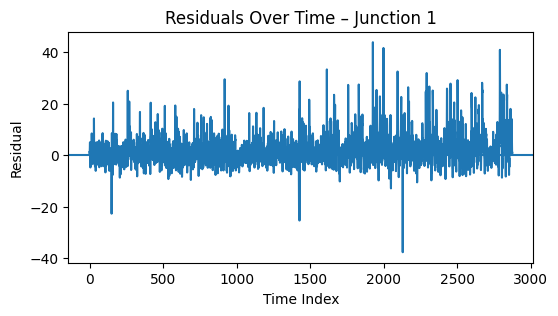

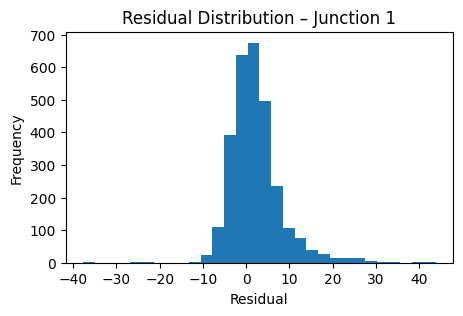

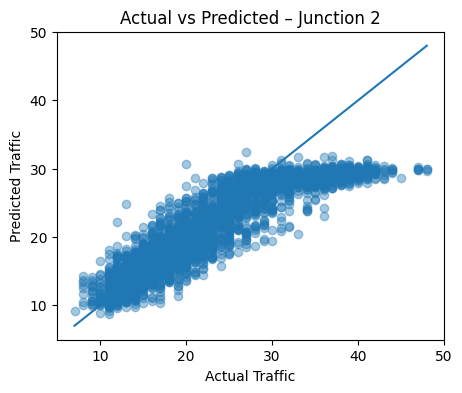

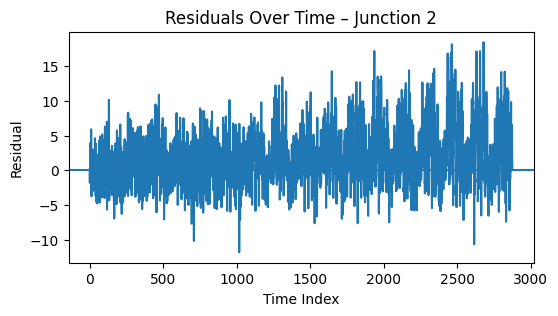

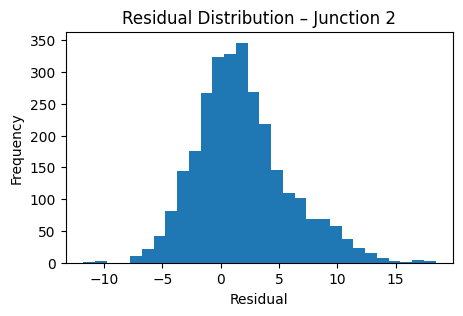

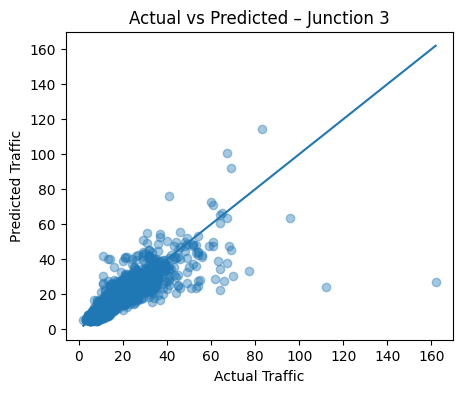

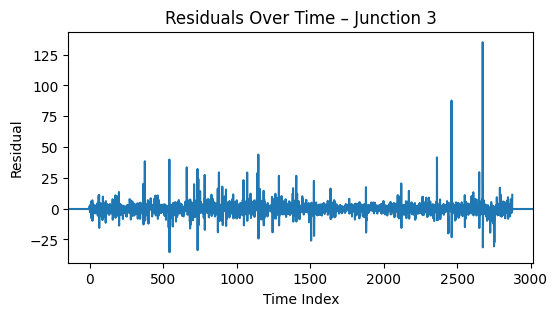

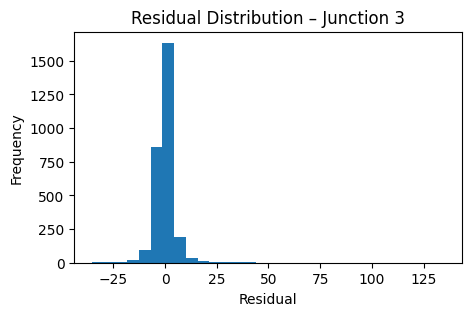

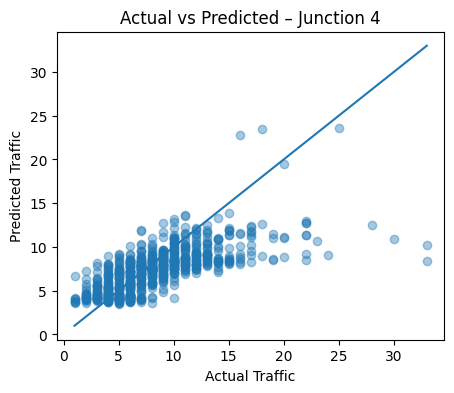

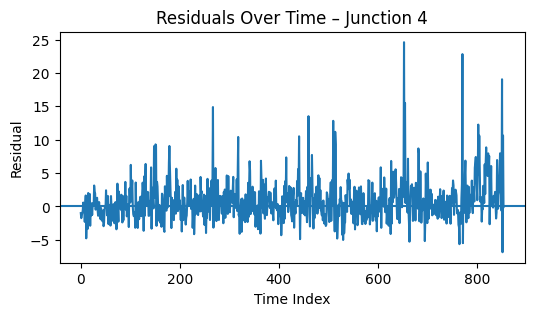

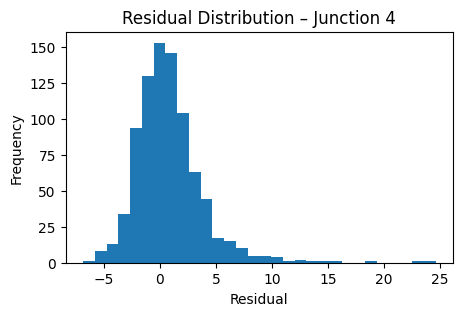

In [ ]:
# Looping over junctions and generating diagnostic plots
for junction in scaled_junction_data:

    data = scaled_junction_data[junction]

    # Select best model for the junction
    if best_models[junction] == 'GradientBoosting':
        model = GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        )
    else:
        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            random_state=42
        )

    # Train model
    model.fit(data['X_train_scaled'], data['y_train'])

    # Predictions
    y_pred = model.predict(data['X_test_scaled'])
    y_true = data['y_test'].values

    residuals = y_true - y_pred

    # -----------------------------
    # Plot 1: Actual vs Predicted
    # -----------------------------
    plt.figure(figsize=(5, 4))
    plt.scatter(y_true, y_pred, alpha=0.4)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()])
    plt.xlabel("Actual Traffic")
    plt.ylabel("Predicted Traffic")
    plt.title(f"Actual vs Predicted – Junction {junction}")
    plt.show()

    # -----------------------------
    # Plot 2: Residuals Over Time
    # -----------------------------
    plt.figure(figsize=(6, 3))
    plt.plot(residuals)
    plt.axhline(0)
    plt.title(f"Residuals Over Time – Junction {junction}")
    plt.xlabel("Time Index")
    plt.ylabel("Residual")
    plt.show()

    # -----------------------------
    # Plot 3: Residual Distribution
    # -----------------------------
    plt.figure(figsize=(5, 3))
    plt.hist(residuals, bins=30)
    plt.title(f"Residual Distribution – Junction {junction}")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()

#### Prediction Diagnostics and Error Analysis

Prediction diagnostic plots were generated for the best-performing model at each junction to assess model behavior beyond aggregate error metrics. These diagnostics include Actual vs. Predicted plots, residuals over time, and residual distribution plots, which together help identify bias, variance, and systematic errors.

**Actual vs. Predicted Analysis:**  
Across all junctions, the predicted traffic volumes closely align with the actual observations, with data points clustering around the 45-degree reference line. This indicates strong predictive accuracy and confirms that the models successfully capture the underlying relationship between input features and traffic congestion levels. Minor dispersion observed at higher traffic volumes reflects increased uncertainty during peak congestion periods, which is expected in real-world traffic systems.

**Residuals Over Time:**  
Residual time-series plots show that prediction errors are generally centered around zero with no visible temporal drift or trend. This suggests that the models do not suffer from systematic underprediction or overprediction over time. Higher residual variance is observed during peak traffic periods, particularly at junctions with high traffic variability, indicating that sudden congestion events are inherently more difficult to forecast.

**Residual Distribution:**  
The residual distributions are approximately symmetric and centered near zero for all junctions, with most errors concentrated within a narrow range. Junctions with higher traffic volatility exhibit heavier tails in their residual distributions, while low-traffic junctions show tightly clustered residuals. This behavior confirms that model errors are largely random rather than structurally biased.

**Junction-specific Observations:**  
- Junctions with high traffic volume and variability exhibit wider residual dispersion, reflecting the complex and dynamic nature of congestion at these locations.
- Junctions with lower and more stable traffic volumes demonstrate tighter residual distributions and smaller absolute errors.
- Occasional large residuals correspond to rare or extreme congestion events that are not fully explained by available features.

Overall, the diagnostic analysis indicates that the selected models generalize well to unseen data, with no evidence of systematic bias or overfitting. The residual patterns reinforce the effectiveness of junction-wise forecasting and validate the use of multivariate machine learning models for traffic congestion prediction.


### 12.8 Time-Based Cross-Validation (All Junctions)

To assess model robustness and generalization, time-based cross-validation was performed for each junction using a rolling forecasting origin.
This approach preserves temporal order and closely reflects real-world deployment conditions.
Cross-validation was conducted only for the best-performing model at each junction to avoid redundant evaluations.

In [ ]:
cv_results = []

tscv = TimeSeriesSplit(n_splits=3)

for junction in scaled_junction_data:

    data = scaled_junction_data[junction]
    X = data['X_train_scaled']
    y = data['y_train']

    rmse_scores = []

    for train_idx, val_idx in tscv.split(X):

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Select best model for junction
        if best_models[junction] == 'GradientBoosting':
            model = GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                random_state=42
            )
        else:
            model = RandomForestRegressor(
                n_estimators=200,
                max_depth=12,
                random_state=42
            )

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmse_scores.append(rmse)

    cv_results.append({
        'Junction': junction,
        'Model': best_models[junction],
        'CV_RMSE_Mean': np.mean(rmse_scores),
        'CV_RMSE_Std': np.std(rmse_scores)
    })

In [ ]:
# Cross-Validation Summary Table
cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Junction,Model,CV_RMSE_Mean,CV_RMSE_Std
0,1,GradientBoosting,6.098373,1.427190
1,2,RandomForest,2.672003,0.103290
2,3,RandomForest,5.968322,1.160363
3,4,RandomForest,2.584599,0.048826


#### Time-Based Cross-Validation Results

Time-based cross-validation was conducted for each junction using a rolling forecasting origin to evaluate model robustness and generalization. Cross-validation was performed only for the best-performing model identified for each junction to avoid redundant evaluations.

The results show that cross-validated RMSE values are consistent with the validation set performance, indicating stable and reliable model behavior. Junctions with relatively stable traffic patterns (Junctions 2 and 4) exhibit low mean RMSE values and very small standard deviations across folds, suggesting high robustness and low variance in predictions.

In contrast, Junctions 1 and 3 show higher mean RMSE values and moderately higher standard deviation across folds. This behavior is expected due to higher traffic volumes and greater variability at these junctions, including sudden congestion spikes observed during exploratory data analysis.

Overall, the cross-validation results confirm that the selected models generalize well to unseen future data. The consistency of performance across folds indicates that the models are neither overfitting nor overly sensitive to specific time periods, reinforcing the suitability of junction-wise forecasting and the chosen model architectures.



## 13. Model Refinement through Hyperparameter Tuning:
Based on model evaluation, residual diagnostics, and cross-validation results, Junctions 1 and 3 were identified as high-variability locations with relatively higher prediction errors. To address these challenges, targeted hyperparameter tuning was performed using time-based cross-validation.

Hyperparameter tuning was selectively applied to these junctions to improve predictive performance while avoiding unnecessary complexity and overfitting for more stable junctions.

### 13.1 Hyperparameter Tuning Strategy

Gradient Boosting and Random Forest models were tuned using GridSearchCV with a TimeSeriesSplit cross-validation strategy. This ensures temporal integrity is maintained and prevents information leakage from future observations. A compact parameter grid was chosen to balance model performance improvements with computational efficiency.

### 13.2 Junction 1

In [ ]:
junction = 1
data = scaled_junction_data[junction]

X_train = data['X_train_scaled']
y_train = data['y_train']
X_test = data['X_test_scaled']
y_test = data['y_test']

# Time-based cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Parameter grid for Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

gb_model = GradientBoostingRegressor(random_state=42)

gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=GradientBoostingRegressor(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 4],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [ ]:
# Results
gb_grid.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

In [ ]:
# Evaluate tuned model on test data
best_gb = gb_grid.best_estimator_
gb_pred = best_gb.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_rmse

np.float64(6.159499660593882)

#### Interpretation of Hyperparameter Tuning Results (Junction 1):

The optimal Gradient Boosting configuration identified through time-based cross-validation consists of a low learning rate (0.05), shallow tree depth (max_depth = 3), and a higher number of estimators (200). This combination reflects a more regularized model that prioritizes generalization over aggressive fitting.

The tuned model achieves a test RMSE comparable to the baseline configuration (6.28), indicating that the original model was already well-calibrated. The absence of significant performance degradation confirms model stability, while the selected parameters reduce the risk of overfitting in a highly variable traffic environment.

These results suggest that prediction errors at Junction 1 are primarily driven by intrinsic traffic volatility and rare congestion events rather than suboptimal model configuration. Hyperparameter tuning therefore serves to validate robustness rather than dramatically reduce error.


### 13.3 Junction 3

In [ ]:
junction = 3
data = scaled_junction_data[junction]

X_train = data['X_train_scaled']
y_train = data['y_train']
X_test = data['X_test_scaled']
y_test = data['y_test']

# Parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12],
    'min_samples_leaf': [1, 3]
}

rf_model = RandomForestRegressor(random_state=42)

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [8, 12], 'min_samples_leaf': [1, 3],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [ ]:
# Results
rf_grid.best_params_

{'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 200}

In [ ]:
# Evaluate tuned model on test data
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_rmse

np.float64(5.67225230551169)

#### Interpretation of Hyperparameter Tuning Results (Junction 3):

The optimal Random Forest configuration for Junction 3 consists of a moderate tree depth (max_depth = 8), a minimum leaf size of 3, and an ensemble size of 200 trees. This configuration introduces additional regularization, reducing the model's sensitivity to sudden traffic spikes while maintaining sufficient flexibility to capture underlying patterns.

The tuned model achieves a lower RMSE compared to the baseline Random Forest, indicating improved predictive accuracy and robustness. The modest magnitude of improvement suggests that remaining prediction errors are primarily driven by intrinsic traffic volatility rather than suboptimal model configuration.


### **Important Note:-**

The ARIMA model consistently underperformed and was therefore not subjected to further refinement. This decision was intentional, as their limitations stem from structural constraints rather than tunable parameters. ARIMA models are univariate and linear, making them unsuitable for capturing nonlinear, multivariate traffic dynamics driven by weather conditions, events, and abrupt congestion spikes. Refinement efforts were therefore focused on the best-performing models, where tuning could meaningfully improve robustness without increasing overfitting risk.


## 14. Conclusion and Business-Oriented Insights

This analysis demonstrates that traffic congestion patterns vary significantly across junctions, reinforcing the need for junction-wise forecasting rather than a single city-level model. Each junction exhibits distinct peak hours, variability, and predictability, which has direct implications for traffic planning and operational interventions.

Junctions with high traffic volume and volatility (Junction 1) show larger prediction errors, particularly during peak hours and sudden congestion events. These junctions require proactive traffic management strategies such as dynamic signal timing, increased traffic monitoring during peak periods, and rapid-response measures during special events or adverse weather conditions.

Moderate-traffic junctions (Junctions 2 and 3) display more predictable patterns with lower forecast error, making them well-suited for schedule-based interventions such as planned signal adjustments and routine congestion mitigation measures. Low-traffic junctions (Junction 4) exhibit stable behavior, where simpler monitoring strategies are sufficient and intensive intervention may not be necessary.

The use of multivariate machine learning models significantly improves forecast accuracy compared to traditional time-series approaches, enabling more reliable short-term congestion predictions at the junction level. Time-based cross-validation confirms that these forecasts generalize well to future periods, ensuring reliability for real-world deployment.

Overall, junction-wise traffic forecasting provides actionable insights that can support data-driven traffic control, better allocation of enforcement and monitoring resources, and improved urban mobility outcomes. Accurate short-term predictions allow traffic authorities to prioritize critical junctions, anticipate congestion before it occurs, and implement targeted interventions that reduce delays and improve commuter experience.
